# UC Berkeley Capstone Project -- Data Analysis & Modelling

This is a notebook for my UC Berkeley Capstone project.

I have a harvester script running in GCP that collects YouTube video metadata and metrics and stores that in a BQ table. 
Because the script is running in an ongoing basis, and I have limited time before I need to turn in the project, I am going to start working with synthetic data integrated with my real data, and gradually shift over to all real data.

- This will allow me start modelling sooner. 
- The synthetic data will be identifiable in the DataFrame.
- I will be storing a Parquet snapshot of the BQ data extract + model version in a GCS Bucket, so that I can always see which specific data + model produced which specific results.

The workflow here is:

1. Create a snapshot of the BQ data 
1. Add the synthetic data rows
1. Store the dataset in a versioned GCS bucket
1. (when modelling) store model vesrion data + stats in a versioned GCS bucket as well.

TODO (jelani):

1. make the snapshotting proces easier to manage with a global flag for on/off and constants for the different model version names, video snapshog version names, etc. The on/off can live in each code blcok where it is needed so that I'm not hunting through code to update it. 
1. Have this all live in a cell at the top of the notebook to make it easy to access and change.
1. Add the newer cut of real data
1. Make the label for synth data split easier to figure out (and set some math to do the split)
1. Add RnadomForrest


In [12]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.snapshot_data as snapshot
from utils.snapshot_model import (
    TrainingData, ModelResult, ModelConfig,
    save_model, list_models,
)
from data_processing.data_cleanup import build_clean_dataset
from data_processing.feature_engineering import engineer_features
from data_processing.synthetic_data import generate_synthetic_data, combine_real_and_synthetic


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix,
    RocCurveDisplay,
)
from xgboost import XGBClassifier




In [ ]:
import os

# =============================================================================
# SNAPSHOT CONFIG
# Edit this cell to control all snapshotting behavior in one place.
# =============================================================================

# Master on/off switch. Set to True (or export TAKE_SNAPSHOT=true in shell)
# only when you intentionally want to write new snapshots to GCS.
TAKE_SNAPSHOT = False

# Version tags — update these before running any snapshot operations.
RAW_DATA_VERSION   = "v3.0_real"
MIXED_DATA_VERSION = "v3.0_mixed_80real"
MODEL_VERSION      = "v3.0"

print(f"TAKE_SNAPSHOT={TAKE_SNAPSHOT}")
print(f"  RAW_DATA_VERSION:   {RAW_DATA_VERSION}")
print(f"  MIXED_DATA_VERSION: {MIXED_DATA_VERSION}")
print(f"  MODEL_VERSION:      {MODEL_VERSION}")
if TAKE_SNAPSHOT:
    print("WARNING: snapshots WILL be written to GCS this run.")

TIER_ORDER = ['S', 'M', 'L']
VERTICAL_ORDER = ['Education', 'Lifestyle', 'Tech']

TAKE_SNAPSHOT=True
  RAW_DATA_VERSION:   v3.0_real
  MIXED_DATA_VERSION: v3.0_mixed_80real
  MODEL_VERSION:      v3.0


In [14]:
def create_new_snapshot(
    version_name: str, additional_notes: str = ""
):
    """
    Creates snapshots in GCS bucket for:
      - Channel baseline data
      - Channel median data
      - Video snapshot data

    Snapshots can be viewed via `snapshot.list_snapshots` and loaded via
    `snapshot.load_videos` and `snapshot.load_baselines`

    version_name: Name like 'v1.0_real'
    additional_notes: Descriptive notes. `version_name` is automatically added.

    Returns: (video_df, baseline_df, median_df, video_meta, baseline_meta)
    """
    video_df, video_meta = snapshot.snapshot_video_data(version_tag=version_name, 
            notes=f"Video data version {version_name}. {additional_notes}",
    )

    baseline_df, median_df, baseline_meta = snapshot.snapshot_baselines(
        version_tag=version_name,
        notes=f"Channel baselines corresponding to {version_name} video snapshot. {additional_notes}",
    )
    return (video_df, baseline_df, median_df, video_meta, baseline_meta)

In [15]:
if TAKE_SNAPSHOT:
    additional_notes = "More triplet rows from a few additional days."
    video_df, baseline_df, median_df, video_meta, baseline_meta = create_new_snapshot(
        version_name=RAW_DATA_VERSION, additional_notes=additional_notes
    )

# See what's available
snapshot.list_snapshots()

/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Saved 20612 rows to /tmp/snapshots_v3.0_real_20612rows_20260328_181425.parquet
Uploaded gs://maduros-dolce-capstone-data/snapshots/snapshots_v3.0_real_20612rows_20260328_181425.parquet
Uploaded gs://maduros-dolce-capstone-data/snapshots/snapshots_v3.0_real_20612rows_20260328_181425_meta.json

--- Snapshot v3.0_real ---
  Rows: 20612
  Polls: {'upload': 7952, '24h': 7610, '7d': 5050}
  Verticals: {'Tech': 7138, 'Lifestyle': 7075, 'Education': 6399}
  GCS path: gs://maduros-dolce-capstone-data/snapshots/snapshots_v3.0_real_20612rows_20260328_181425.parquet


/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Pulled 28754 baseline video rows (972 channels)
Pulled 972 baseline median rows
Uploaded gs://maduros-dolce-capstone-data/snapshots/baselines_v3.0_real_28754rows_20260328_181445.parquet
Uploaded gs://maduros-dolce-capstone-data/snapshots/medians_v3.0_real_972rows_20260328_181445.parquet

--- Baseline Snapshot v3.0_real ---
  Baseline videos: 28754 (972 channels)
  Baseline medians: 972
Found 11 snapshots:

  [baselines] v1.0_model_mixed66  |  28544 baseline videos, 965 medians  |  2026-03-25
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_model_mixed66_28544rows_20260325_035026.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_model_mixed66_965rows_20260325_035026.parquet

  [baselines] v1.0_real  |  28544 baseline videos, 965 medians  |  2026-03-22
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_real_28544rows_20260322_184459.parquet
                     gs://maduros-dolce-capstone-data/sn

In [16]:
# Load an existing snapshot (no new version created) when loading this notebook,
# as snapshotted df may not be in memory.
df_videos, meta = snapshot.load_videos(RAW_DATA_VERSION)
df_baselines, df_medians, baseline_meta = snapshot.load_baselines(RAW_DATA_VERSION)

print(f"Video snapshots: {len(df_videos)}")
print(f"Baseline videos: {len(df_baselines)}")
print(f"Baseline medians: {len(df_medians)}")

df_videos.head()

Loaded snapshot 'v3.0_real': 20612 rows from 2026-03-28
  Polls: {'upload': 7952, '24h': 7610, '7d': 5050}
Loaded baselines 'v3.0_real': 28754 baseline videos, 972 median rows (972 channels)
Video snapshots: 20612
Baseline videos: 28754
Baseline medians: 972


,video_id,poll_timestamp,channel_id,channel_handle,title,view_count,like_count,comment_count,face_count,brightness,...,description,tags,duration_seconds,category_id,category_name,published_at,poll_label,hours_since_publish,subscriber_count,contains_synthetic_media
0,JA3JHCIklgY,2026-03-28 10:05:04.960383+00:00,UC8IGjadffa4uU1Y07FplrFA,@brad3dofficial3051,CONGRATS! NAA SA ANGLE GUIDE ATONG GIHATAG 617...,471,59,5,0,72.133368,...,,[],560,22,People & Blogs,2026-03-28 07:17:11+00:00,upload,2.80,59200,False
1,zbVf2hgxMD0,2026-03-28 10:05:04.960383+00:00,UCEl8atS3r3w_rcGvCpnUq1A,@luckyjmixtv,BIG CONGRATS 👏 BUGHA TARGETIC BALIK LAGI 71 17...,855,106,0,1,94.708796,...,,[],1718,22,People & Blogs,2026-03-28 07:56:53+00:00,upload,2.14,39600,False
2,VZnV7eqbFU0,2026-03-28 10:05:04.960383+00:00,UCeTVoczn9NOZA9blls3YgUg,@englishclass101,"Active Voice, Appearance, and Style",441,36,0,1,86.417610,...,https://tinyurl.com/khk6hcks Get your Free Lif...,"[Tutorial, English, how to, learn, English cul...",7959,27,Education,2026-03-28 09:30:00+00:00,upload,0.58,8660000,False
3,txJ3M0tLnzU,2026-03-28 10:05:04.960383+00:00,UC2QQdHRaMtii4SKoGjIEuhQ,@laptopfactory,NAKA 3K DISCOUNT AT 3 FREEBIES KA!!!,19,0,0,0,95.136111,...,,[],23,28,Science & Technology,2026-03-28 09:00:56+00:00,upload,1.07,226000,False
4,rWvKdd-ScCE,2026-03-28 10:05:04.960383+00:00,UC4alTWCTl6y_jt2_jgmxPZQ,@teluguconnects_,Indonesia is the loudest‼️,19237,1037,3,1,30.727402,...,,[],46,24,Entertainment,2026-03-28 04:28:00+00:00,upload,5.62,292000,False


In [17]:
df_baselines.head()

,channel_id,channel_handle,vertical,tier,video_id,title,published_at,duration_seconds,category_id,category_name,view_count,like_count,comment_count,subscriber_count,baseline_polled_at
0,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,O9v-jrknqfI,"Compound Formulas & Naming Explained (Ionic, ...",2026-03-04 01:00:20+00:00,1199,24,Entertainment,25,4,2,3100,2026-03-13 06:48:44.305022+00:00
1,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,gxXqC4jhJMw,"Covalent Compounds (Concepts, Formulas, & Nami...",2026-02-26 20:14:06+00:00,444,24,Entertainment,9,3,0,3100,2026-03-13 06:48:44.305022+00:00
2,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,WFV-sjHKgKw,Polyatomic Ions (Writing Compound Formulas & N...,2026-02-26 00:00:39+00:00,557,24,Entertainment,33,3,0,3100,2026-03-13 06:48:44.305022+00:00
3,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,Mi4iKzZ1w9M,"Ionic Compounds (Formulas, Naming, & Transitio...",2026-02-25 00:00:33+00:00,892,24,Entertainment,13,3,0,3100,2026-03-13 06:48:44.305022+00:00
4,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,Education,S,N5DlbERakjc,"4 Rotation Examples (Kinematics, Torque, Momen...",2026-02-19 20:16:16+00:00,1401,24,Entertainment,23,2,0,3100,2026-03-13 06:48:44.305022+00:00


In [18]:
df_medians.head()

,channel_id,channel_handle,baseline_video_count,median_views,median_likes,median_comments,median_engagement_rate
0,UChICxLstKUHBhkfoEuOn0wg,@beatphysics,30,63,2,0,0.022059
1,UClwfFicJWu0SF33fkks9Ufg,@mealpreponfleek,30,2866,41,2,0.015188
2,UCPUmTEzr8krG5POZ7nm0tOA,@unitfourzero,30,268,6,1,0.022059
3,UCX5ROxzDUKPuGCk4p-KqFjA,@cybersecuritytelugu,30,303,10,2,0.036160
4,UColPtFDyDoytKMaL88VXiaw,@saasmasterycom,30,1024,23,0,0.030864


In [19]:
print(df_videos.describe())

print(df_videos.info())

          view_count   like_count  comment_count  face_count    brightness  \
count        20612.0      20612.0        20612.0     20612.0  20612.000000   
mean    37139.790025  1300.976713      67.451921    0.834029     77.087307   
std    330312.291084  6948.564158     319.482127    0.999326     28.249234   
min              0.0          0.0            0.0         0.0      0.000000   
25%            250.0         10.0            0.0         0.0     58.851916   
50%           1546.0         69.0            4.0         1.0     75.052633   
75%           9742.5        440.0           25.0         1.0     92.478802   
max       25826937.0     381245.0        12582.0        14.0    213.228414   

       colorfulness  duration_seconds  hours_since_publish  subscriber_count  
count  20612.000000           20612.0         20612.000000           20612.0  
mean      42.453923       1098.445614            47.330897    1470794.312536  
std       23.571466       2643.083078            73.112757  

In [20]:
# Initial cleaning

# NULL value in contains_synthetic_media means that the video couldn't be asssessed (e.g. private or deleted).
# execlude those
df_videos.dropna(subset=["contains_synthetic_media"], inplace=True)

# Build the df with baseline metrics inlined 
df_clean = build_clean_dataset(df_videos, df_medians)
df_model = engineer_features(df_clean)

print(df_model.head())

Building clean dataset

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 4984 (dropped 2886 incomplete)
  Pivoted shape: (5047, 34)

[2/3] Joining baseline medians...
  Baseline join: 5047/5047 videos matched a channel median

[3/3] Cleaning data...
  Cleaned: 5047 rows × 40 columns

Clean dataset: 5047 rows × 40 columns
Engineering features

[1/7] Computing target variable...
  Target distribution: 56.0% above baseline, 44.0% below

[2/7] Computing velocity features...
  Computed velocity for: ['view_count', 'like_count', 'comment_count', 'subscriber_count']

[3/7] Computing subscriber-normalized metrics...
  Computed subscriber-normalized metrics for upload/24h/7d

[4/7] Computing categorical features...
  Title categories:
title_category
neutral        3245
exclamation     561
all_caps        533
question        416
listicle        158
how_to           64
clickbait        51
emoji_heavy      19
  Description categories:
desc_category
link_heavy        1326
minimal           12

In [21]:
def get_synth_rows_proportion(num_real_rows: int, target_real_pct: float):
    return math.floor(float(num_real_rows) / target_real_pct) - num_real_rows

In [22]:
target_synth_rows = get_synth_rows_proportion(num_real_rows=len(df_model), target_real_pct=0.8)
print(f"target_synth_rows: {target_synth_rows}")

# Generate synthetic rows (baselines from real channels)
df_synth = generate_synthetic_data(df_model, num_rows=target_synth_rows, seed=42)

# Combine
df_combined = combine_real_and_synthetic(df_model, df_synth)

df_combined.sample(8)

target_synth_rows: 1261
Generating 1261 synthetic rows

[1/5] Preparing data for synthesis...
  Input shape: (5047, 22)

[2/5] Fitting GaussianCopulaSynthesizer...


/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


  Fit complete

[3/5] Sampling synthetic rows...
  Generated 1261 rows

[4/5] Assigning real channels and baselines...
  Assigned 1261 synthetic rows to 430 real channels
  Baseline match: 1261/1261

[5/5] Postprocessing and recomputing features...

Synthetic data: 1261 rows
Assigned to 430 real channels
Target balance: {1: 772, 0: 489}
Combined dataset: 6308 rows (5047 real + 1261 synthetic, 20% synthetic)


/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/data_processing/synthetic_data.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(
/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/data_processing/synthetic_data.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(


,video_id,channel_id,channel_handle,title,description,tags,duration_seconds,category_id,category_name,published_at,...,desc_link_count,desc_hashtag_count,tag_count,has_tags,publish_hour,publish_dayofweek,publish_is_weekend,is_short,duration_minutes,contains_synthetic_data
1893,f5MSAu_z3jo,UCVvwbez-BNlWvbxtpOx0MGQ,@historyla,LA COMIDA DEL MAÑANA 🐓 - EXPERIMENTOS MONSTRUOSOS,¿Sabías que el pollo que comes hoy nació en un...,[],539,24,Entertainment,2026-03-20 22:00:00+00:00,...,3,0,0,0,22,4,0,0,8.983333,False
351,ubkP6QtbsHU,UC0k238zFx-Z8xFH0sxCrPJg,@archdigest,The Most Pointless Part of Jimmy Butler's House,Jimmy Butler roasts his own foyer. From art to...,[],23,24,Entertainment,2026-03-13 18:00:03+00:00,...,2,5,0,0,18,4,0,1,0.383333,False
1498,9EaTm2XeMc8,UCCpXwXA5iWCd2F0bzJnAZ9g,@feenysfitnessjourney515,🔴 Let's Do Some Cardio Before The Weekend!🔥🔥🔥,paypal.com/donate/?business=9ZZLDVLBJ7U9E&no_r...,[],1796,17,Sports,2026-03-21 12:56:45+00:00,...,0,5,0,0,12,5,1,0,29.933333,False
5813,syn-000766,UC4alTWCTl6y_jt2_jgmxPZQ,@teluguconnects_,[Synthetic],[Synthetic],[],1,27,Synthetic,NaT,...,0,0,0,0,0,0,0,1,0.016667,True
599,SdbsIW4dMSE,UCTMd_rwB7b3RZM6o6wc-KkQ,@bhavanashealthycooking,Shahi Lassi.#short #shorts #food #healthyfood,,[],25,28,Science & Technology,2026-03-15 07:05:38+00:00,...,0,0,0,0,7,6,1,1,0.416667,False
3950,WBsP_U5sPCQ,UCEdf-ErYgobzpgqbznA5DfQ,@stayfitmom,My Viral Bang Bang Chicken Meal Prep Bowls | H...,If you need an easy high protein meal prep rec...,[],95,22,People & Blogs,2026-03-14 01:23:23+00:00,...,1,5,0,0,1,5,1,0,1.583333,False
1038,zrij9Du2C4E,UCvi_51BRybgjJuFpmutLh3g,@collegeaidpro,3.18.26 Financial Aid Offers Are Not Final: Ho...,http://www.collegeaidpro.com\nhttp://www.mycap...,[],4071,27,Education,2026-03-19 13:36:23+00:00,...,2,0,0,0,13,3,0,0,67.85,False
3113,q2F08aIW5xQ,UC--ddwuPMF5UvDhwHrPrJHg,@plothubละครจน,🌵พากย์ไทย |เปาบุ้นจิ้นตำนานผู้เที่ยงธรรมEP16Ri...,Drama name: รักต้องห้ามเทพธิดาLove Of The Godd...,[],0,22,People & Blogs,2026-03-10 13:00:06+00:00,...,2,16,0,0,13,1,0,1,0.0,False


In [24]:
if TAKE_SNAPSHOT:
    notes = f"{len(df_model)} real + {target_synth_rows} synthetic (GaussianCopula seed=42), real channel baselines"
    snapshot_meta = snapshot.save_snapshot(
        df=df_combined, version_tag=MIXED_DATA_VERSION, notes=notes
    )

# Use this to load so we aren't creating a snapshot every time the notebook runs
df_combined, _ = snapshot.load_videos(MIXED_DATA_VERSION)

df_train = df_combined

# Never evaluate on synthetic data
df_eval = df_combined[~df_combined["contains_synthetic_data"]]

df_train.sample(5)


--- Snapshot v3.0_mixed_80real ---
  Rows: 6308 (5047 real, 1261 synthetic)
  Polls: {}
  GCS: gs://maduros-dolce-capstone-data/snapshots/snapshots_v3.0_mixed_80real_6308rows_20260328_181523.parquet
Loaded snapshot 'v3.0_mixed_80real': 6308 rows from 2026-03-28
  Polls: {}


,video_id,channel_id,channel_handle,title,description,tags,duration_seconds,category_id,category_name,published_at,...,desc_link_count,desc_hashtag_count,tag_count,has_tags,publish_hour,publish_dayofweek,publish_is_weekend,is_short,duration_minutes,contains_synthetic_data
3915,6D62IpJ2AiA,UCuPkgKp2-9zMuVIr-eAFjyw,@spacedustdoc,A New Way to Travel Faster Than Light Itself P...,Subscribe for more space mysteries: https://w...,[],11211,28,Science & Technology,2026-03-18 20:00:06+00:00,...,1,10,0,0,20,2,0,0,186.85,False
2888,i0Xou3amrNE,UCV-yCAXMS-nWrHtORuDfSuQ,@odyssey,Forensic Geologist Investigates North America'...,"Long before Columbus set sail, a massive indus...",[],2580,1,Film & Animation,2026-03-11 22:00:45+00:00,...,2,0,0,0,22,2,0,0,43.0,False
5936,syn-000889,UCDV46H64m7KlQeA5fW2BvXA,@rumahmudah,[Synthetic],[Synthetic],[],668,27,Synthetic,NaT,...,0,0,0,0,0,0,0,0,11.133333,True
3608,YaaZPXjTx7o,UCOAymJWZTZ7j2CSfqaZnAKw,@sehrishluqmanvlogss,Marwah & Abdul Rahman's Book fair at School | ...,Marwah & Abdul Rahman's Book fair at School | ...,[],748,22,People & Blogs,2026-03-15 13:30:36+00:00,...,1,0,0,0,13,6,1,0,12.466667,False
1457,_Xe8IEsscds,UCn2YKsCiDpL3UjxIm4-RCoQ,@everythingelectricshow,2030 Is Closer Than You Think | In the Car wit...,In this special episode of the Everything Elec...,[],3058,28,Science & Technology,2026-03-09 05:00:30+00:00,...,9,22,0,0,5,0,0,0,50.966667,False


In [25]:
# --- Define feature columns (exclude IDs, text, timestamps, target, metadata) ---

# Add 7d metric columns to the exclusion list
EXCLUDE_7D = [c for c in df_combined.columns if c.endswith('_7d')]
print(f"Excluding 7d features: {EXCLUDE_7D}")

EXCLUDE_COLS = [
    # IDs and text
    'video_id', 'channel_id', 'channel_handle', 'title', 'description', 'tags',
    'category_id', 'category_name',
    # Timestamps
    'published_at', 'poll_timestamp_upload', 'poll_timestamp_24h', 'poll_timestamp_7d',
    # Target and intermediate
    'above_baseline', 'engagement_7d', 'baseline_engagement',
    # Metadata flags
    'contains_synthetic_data', 'contains_synthetic_media',
    # Baseline raw (already captured in baseline_engagement)
    'baseline_channel_handle', 'baseline_video_count',
    'baseline_median_views', 'baseline_median_likes',
    'baseline_median_comments', 'baseline_median_engagement_rate',
    # Categorical groupings (use the encoded versions instead)
    'vertical', 'tier',
    # Redundant with duration_seconds
    'duration_minutes',
    # Part of the data harvesting process, not useful for modelling
    'hours_since_publish_upload',
    # Superseded by has_face (binary flag is more reliable signal)
    'face_count',
]

EXCLUDE_COLS.extend(EXCLUDE_7D)

feature_cols = [c for c in df_combined.columns if c not in EXCLUDE_COLS]
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)

Excluding 7d features: ['view_count_7d', 'like_count_7d', 'comment_count_7d', 'subscriber_count_7d', 'hours_since_publish_7d', 'poll_timestamp_7d', 'engagement_7d', 'views_per_sub_7d', 'likes_per_sub_7d', 'comments_per_sub_7d']

Feature columns (36):
['duration_seconds', 'brightness', 'colorfulness', 'view_count_upload', 'like_count_upload', 'comment_count_upload', 'subscriber_count_upload', 'view_count_24h', 'like_count_24h', 'comment_count_24h', 'subscriber_count_24h', 'hours_since_publish_24h', 'baseline_baseline_video_count', 'view_count_velocity_24h', 'like_count_velocity_24h', 'comment_count_velocity_24h', 'subscriber_count_velocity_24h', 'views_per_sub_upload', 'likes_per_sub_upload', 'comments_per_sub_upload', 'views_per_sub_24h', 'likes_per_sub_24h', 'comments_per_sub_24h', 'title_category', 'desc_category', 'title_length', 'title_word_count', 'desc_length', 'desc_link_count', 'desc_hashtag_count', 'tag_count', 'has_tags', 'publish_hour', 'publish_dayofweek', 'publish_is_weeke

In [26]:
# === Split: real data only for evaluation ===

df_real = df_combined[~df_combined['contains_synthetic_data']].copy()
df_synth_rows = df_combined[df_combined['contains_synthetic_data']].copy()

print(f"Real rows:      {len(df_real)}")
print(f"Synthetic rows: {len(df_synth_rows)}")

# Split real data into train/test (stratified on target)
X_real = df_real[feature_cols]
y_real = df_real['above_baseline']

X_real_train, X_test, y_real_train, y_test = train_test_split(
    X_real, y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real,
)

# Add synthetic rows to training set only
X_synth = df_synth_rows[feature_cols]
y_synth = df_synth_rows['above_baseline']

X_train = pd.concat([X_real_train, X_synth], ignore_index=True)
y_train = pd.concat([y_real_train, y_synth], ignore_index=True)

# Handle NaN/inf
X_train = X_train.fillna(0).replace([np.inf, -np.inf], 0)
X_test = X_test.fillna(0).replace([np.inf, -np.inf], 0)

print(f"\nTraining set: {len(X_train)} rows "
      f"({len(X_real_train)} real + {len(X_synth)} synthetic)")
print(f"Test set:     {len(X_test)} rows (100% real)")
print(f"\nTarget balance (train): {y_train.value_counts().to_dict()}")
print(f"Target balance (test):  {y_test.value_counts().to_dict()}")

# Scale for LR (RF and XGBoost use unscaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Real rows:      5047
Synthetic rows: 1261

Training set: 5298 rows (4037 real + 1261 synthetic)
Test set:     1010 rows (100% real)

Target balance (train): {1: 3032, 0: 2266}
Target balance (test):  {1: 566, 0: 444}


In [27]:
# === Model 1: Logistic Regression with L1 (LASSO) ===

model_lr = LogisticRegression(
    penalty='l1',
    solver='saga',       # supports L1
    C=1.0,               # inverse regularization strength
    max_iter=5000,
    random_state=42,
)
model_lr.fit(X_train_scaled, y_train)

# Predictions on real-only test set
y_pred = model_lr.predict(X_test_scaled)
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("Logistic Regression (L1) — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Logistic Regression (L1) — Evaluated on Real Data Only

ROC-AUC: 0.6557

                precision    recall  f1-score   support

Below Baseline       0.64      0.42      0.51       444
Above Baseline       0.64      0.81      0.72       566

      accuracy                           0.64      1010
     macro avg       0.64      0.62      0.61      1010
  weighted avg       0.64      0.64      0.62      1010

Confusion Matrix:
[[187 257]
 [106 460]]


In [28]:
# === Feature Importance (L1 coefficients) ===

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_lr.coef_[0],
    'abs_coefficient': np.abs(model_lr.coef_[0]),
}).sort_values('abs_coefficient', ascending=False)

# Features that L1 zeroed out (not useful)
zeroed = coef_df[coef_df['coefficient'] == 0]
print(f"Features zeroed out by L1: {len(zeroed)}/{len(coef_df)}")

# Top 20 most important
print("\nTop 20 Features:")
print(coef_df.head(20).to_string(index=False))

Features zeroed out by L1: 2/36

Top 20 Features:
                   feature  coefficient  abs_coefficient
            view_count_24h    -1.509711         1.509711
            like_count_24h     1.119677         1.119677
      subscriber_count_24h    -0.717954         0.717954
   subscriber_count_upload     0.670445         0.670445
   view_count_velocity_24h    -0.437854         0.437854
         views_per_sub_24h    -0.420885         0.420885
         view_count_upload     0.297052         0.297052
   like_count_velocity_24h     0.283425         0.283425
                  is_short    -0.251308         0.251308
         likes_per_sub_24h     0.234518         0.234518
          title_word_count    -0.213234         0.213234
         like_count_upload    -0.208866         0.208866
              title_length     0.139656         0.139656
               desc_length     0.127591         0.127591
comment_count_velocity_24h     0.123989         0.123989
            title_category    -0.10379

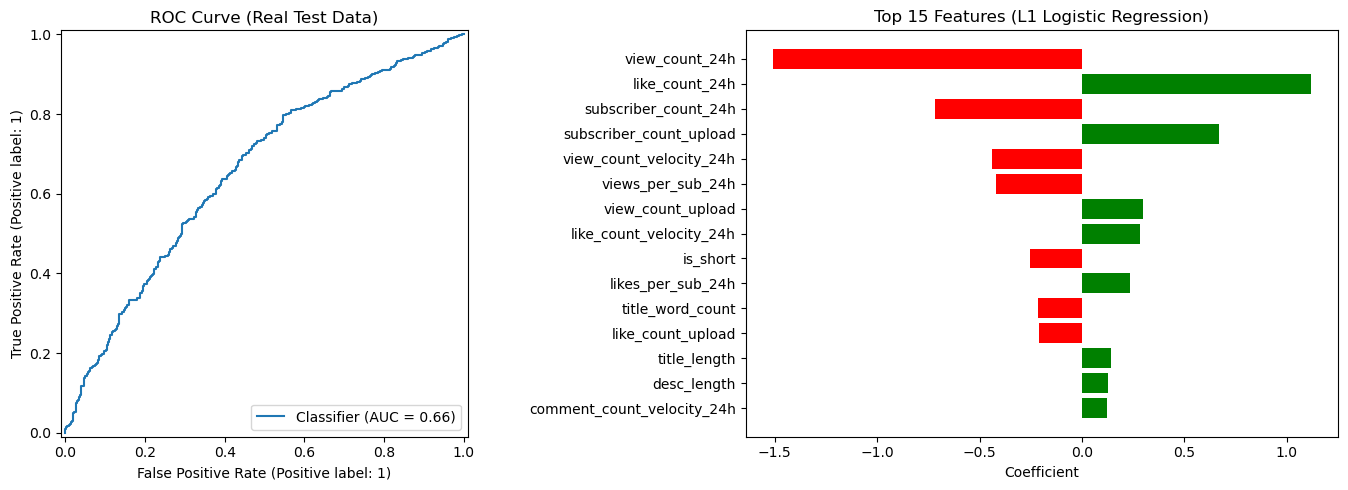

In [29]:
# === Visualizations ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title('ROC Curve (Real Test Data)')

# Top 15 feature coefficients
top_15 = coef_df.head(15)
colors = ['green' if c > 0 else 'red' for c in top_15['coefficient']]
axes[1].barh(top_15['feature'], top_15['coefficient'], color=colors)
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Top 15 Features (L1 Logistic Regression)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [30]:
# No scaling needed for RF (tree-based, scale-invariant)
model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
model_rf.fit(X_train, y_train)  # unscaled features

# Predictions on real-only test set
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Random Forest — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")

Random Forest — Evaluated on Real Data Only

ROC-AUC: 0.8246

                precision    recall  f1-score   support

Below Baseline       0.77      0.66      0.71       444
Above Baseline       0.76      0.84      0.80       566

      accuracy                           0.76      1010
     macro avg       0.76      0.75      0.75      1010
  weighted avg       0.76      0.76      0.76      1010

Confusion Matrix:
[[291 153]
 [ 89 477]]


In [31]:
# === RF Feature Importance ===

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_rf.feature_importances_,
}).sort_values('importance', ascending=False)

print("Top 20 Features (Random Forest):")
print(importance_df.head(20).to_string(index=False))

Top 20 Features (Random Forest):
                   feature  importance
            view_count_24h    0.073347
   view_count_velocity_24h    0.064544
         likes_per_sub_24h    0.058814
         views_per_sub_24h    0.058601
            like_count_24h    0.058543
   like_count_velocity_24h    0.052874
          duration_seconds    0.050206
         view_count_upload    0.039521
      views_per_sub_upload    0.037383
      likes_per_sub_upload    0.035157
              colorfulness    0.032643
         like_count_upload    0.031265
                brightness    0.031195
   subscriber_count_upload    0.030580
      subscriber_count_24h    0.029392
      comments_per_sub_24h    0.029059
   hours_since_publish_24h    0.027164
comment_count_velocity_24h    0.026315
              title_length    0.025566
         comment_count_24h    0.023738


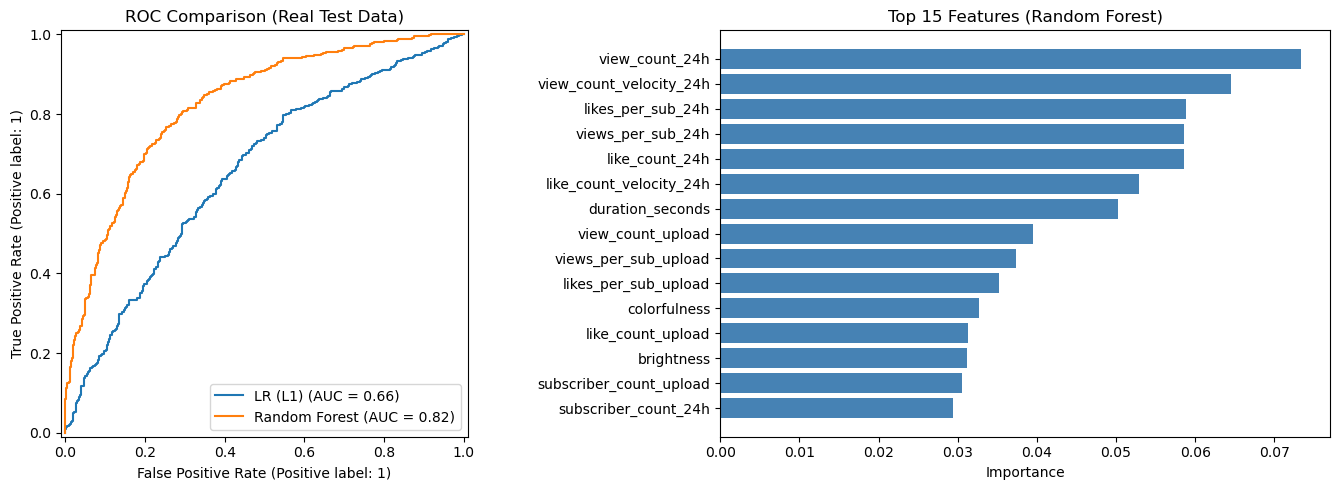

In [32]:
# === Side-by-side comparison ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves compared
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], name='LR (L1)')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf, ax=axes[0], name='Random Forest')
axes[0].set_title('ROC Comparison (Real Test Data)')

# RF top 15 feature importances
top_15_rf = importance_df.head(15)
axes[1].barh(top_15_rf['feature'], top_15_rf['importance'], color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features (Random Forest)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [33]:
# === Model 3: XGBoost ===

model_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
)
model_xgb.fit(X_train, y_train)  # unscaled, like RF

# Predictions on real-only test set
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("=" * 60)
print("XGBoost — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")

XGBoost — Evaluated on Real Data Only

ROC-AUC: 0.8303

                precision    recall  f1-score   support

Below Baseline       0.74      0.71      0.72       444
Above Baseline       0.78      0.80      0.79       566

      accuracy                           0.76      1010
     macro avg       0.76      0.76      0.76      1010
  weighted avg       0.76      0.76      0.76      1010

Confusion Matrix:
[[315 129]
 [111 455]]


In [34]:
# === XGBoost Feature Importance ===

importance_df_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_,
}).sort_values('importance', ascending=False)

print("Top 20 Features (XGBoost):")
print(importance_df_xgb.head(20).to_string(index=False))

Top 20 Features (XGBoost):
                      feature  importance
                     is_short    0.072386
baseline_baseline_video_count    0.062001
               like_count_24h    0.046228
               view_count_24h    0.043293
            views_per_sub_24h    0.041453
            likes_per_sub_24h    0.037648
      like_count_velocity_24h    0.034699
      view_count_velocity_24h    0.034668
               title_category    0.032783
             duration_seconds    0.027879
            comment_count_24h    0.027598
           desc_hashtag_count    0.026867
   comment_count_velocity_24h    0.026485
              desc_link_count    0.025714
         comments_per_sub_24h    0.025626
                 publish_hour    0.025418
      subscriber_count_upload    0.025311
                desc_category    0.025113
      comments_per_sub_upload    0.025071
         comment_count_upload    0.025061


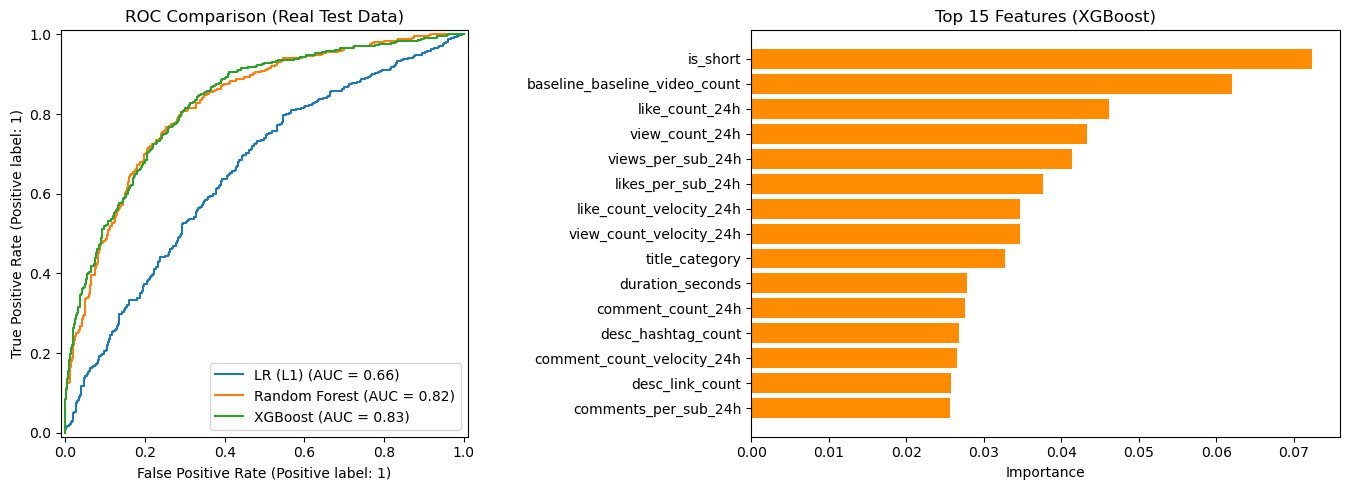

In [35]:
# === All three models compared ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], name='LR (L1)')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf, ax=axes[0], name='Random Forest')
RocCurveDisplay.from_predictions(y_test, y_pred_proba_xgb, ax=axes[0], name='XGBoost')
axes[0].set_title('ROC Comparison (Real Test Data)')

top_15_xgb = importance_df_xgb.head(15)
axes[1].barh(top_15_xgb['feature'], top_15_xgb['importance'], color='darkorange')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features (XGBoost)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [63]:
# === Model comparison table: precision, recall, F1, support, accuracy, AUC ===

def _model_report(name, y_true, y_pred, y_pred_proba):
    r = classification_report(
        y_true, y_pred,
        target_names=['Below Baseline', 'Above Baseline'],
        output_dict=True,
    )
    return {
        ('Below Baseline', 'Precision'): round(r['Below Baseline']['precision'], 3),
        ('Below Baseline', 'Recall'):    round(r['Below Baseline']['recall'], 3),
        ('Below Baseline', 'F1'):        round(r['Below Baseline']['f1-score'], 3),
        ('Below Baseline', 'Support'):   int(r['Below Baseline']['support']),
        ('Above Baseline', 'Precision'): round(r['Above Baseline']['precision'], 3),
        ('Above Baseline', 'Recall'):    round(r['Above Baseline']['recall'], 3),
        ('Above Baseline', 'F1'):        round(r['Above Baseline']['f1-score'], 3),
        ('Above Baseline', 'Support'):   int(r['Above Baseline']['support']),
        ('Overall', 'Accuracy'):         round(r['accuracy'], 3),
        ('Overall', 'ROC-AUC'):          round(roc_auc_score(y_true, y_pred_proba), 3),
    }

rows = {
    'LR (L1)':        _model_report('LR (L1)',       y_test, y_pred,     y_pred_proba),
    'Random Forest':  _model_report('Random Forest', y_test, y_pred_rf,  y_pred_proba_rf),
    'XGBoost':        _model_report('XGBoost',       y_test, y_pred_xgb, y_pred_proba_xgb),
}

df_comparison = pd.DataFrame(rows).T
df_comparison.index.name = 'Model'
df_comparison.columns = pd.MultiIndex.from_tuples(df_comparison.columns)

# Highlight best value per column (excluding Support, which is fixed)
highlight_cols = [c for c in df_comparison.columns if c[1] != 'Support']
df_comparison.style \
    .highlight_max(subset=highlight_cols, color='#d4edda') \
    .format({c: '{:.3f}' for c in highlight_cols})

In [64]:
training_data = TrainingData.from_splits(X_train, y_train, X_test, y_test, X_synth)

if TAKE_SNAPSHOT:
    # Save Logistic Regression
    result_lr = ModelResult.from_sklearn(model_lr, X_test_scaled, y_test, feature_cols)
    config_lr = ModelConfig.from_model(model_lr)
    save_model(
        model=model_lr,
        scaler=scaler,
        feature_cols=feature_cols,
        version_tag=f"{MODEL_VERSION}_lr_l1",
        data_snapshot_tag=MIXED_DATA_VERSION,
        training_data=training_data,
        result=result_lr,
        config=config_lr,
        notes="Clean LR baseline, all 7d features excluded",
    )

    # Save Random Forest
    result_rf = ModelResult.from_sklearn(model_rf, X_test, y_test, feature_cols)
    config_rf = ModelConfig.from_model(model_rf)
    save_model(
        model=model_rf,
        scaler=None,
        feature_cols=feature_cols,
        version_tag=f"{MODEL_VERSION}_rf",
        data_snapshot_tag=MIXED_DATA_VERSION,
        training_data=training_data,
        result=result_rf,
        config=config_rf,
        notes="Random Forest, unscaled features, same split as v1.0_lr_l1",
    )

    # Save XGBoost
    result_xgb = ModelResult.from_sklearn(model_xgb, X_test, y_test, feature_cols)
    config_xgb = ModelConfig.from_model(model_xgb)
    save_model(
        model=model_xgb,
        scaler=None,
        feature_cols=feature_cols,
        version_tag=f"{MODEL_VERSION}_xgb",
        data_snapshot_tag=MIXED_DATA_VERSION,
        training_data=training_data,
        result=result_xgb,
        config=config_xgb,
        notes="XGBoost, unscaled features, same split as v1.0_lr_l1",
    )

# Compare all saved models
list_models()

Found 9 models:

  v1.0_lr_l1  |  LogisticRegression  |  AUC: 0.6258  |  2100 real + 5000 synth
    Data: v1.0_model_mixed66  |  2026-03-26
    Notes: Clean LR baseline, all 7d features excluded

  v1.0_rf  |  RandomForest  |  AUC: 0.7595  |  2100 real + 5000 synth
    Data: v1.0_model_mixed66  |  2026-03-26
    Notes: Random Forest, unscaled features, same split as v1.0_lr_l1

  v1.0_xgb  |  XGBoost  |  AUC: 0.7703  |  2100 real + 5000 synth
    Data: v1.0_model_mixed66  |  2026-03-26
    Notes: XGBoost, unscaled features, same split as v1.0_lr_l1

  v2.0_lr_l1  |  LogisticRegression  |  AUC: 0.6464  |  3255 real + 1743 synth
    Data: v2.0_mixed_70real  |  2026-03-26
    Notes: Clean LR baseline, all 7d features excluded

  v2.0_rf  |  RandomForest  |  AUC: 0.7966  |  3255 real + 1743 synth
    Data: v2.0_mixed_70real  |  2026-03-26
    Notes: Random Forest, unscaled features, same split as v1.0_lr_l1

  v2.0_xgb  |  XGBoost  |  AUC: 0.7971  |  3255 real + 1743 synth
    Data: v2.0_m

In [ ]:
# Debugging
#snapshot.list_snapshots()

# Compare all saved models
#list_models()

Found 12 snapshots:

  [baselines] v1.0_model_mixed66  |  28544 baseline videos, 965 medians  |  2026-03-25
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_model_mixed66_28544rows_20260325_035026.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_model_mixed66_965rows_20260325_035026.parquet

  [baselines] v1.0_real  |  28544 baseline videos, 965 medians  |  2026-03-22
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_real_28544rows_20260322_184459.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_real_965rows_20260322_184459.parquet

  [baselines] v2.0_real  |  28724 baseline videos, 971 medians  |  2026-03-26
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v2.0_real_28724rows_20260326_061729.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v2.0_real_971rows_20260326_061729.parquet

  [baselines] v3.0_